In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12


def cfc(signal, time):
    signal = np.asarray(signal)
    time = np.asarray(time)

    dt = np.mean(np.diff(time))
    cfc = 1000  # CFC 1000
    wd = 2 * np.pi * cfc / 0.6 * 1.25
    wa = np.tan(wd * dt / 2.0)
    a0 = wa**2 / (1 + wa**2 + np.sqrt(2) * wa)
    a1 = 2 * a0
    a2 = a0
    b1 = -2 * (wa**2 - 1) / (1 + wa**2 + np.sqrt(2) * wa)
    b2 = (-1 + np.sqrt(2) * wa - wa**2) / (1 + wa**2 + np.sqrt(2) * wa)
    y = np.zeros_like(signal)
    for i in range(2, len(signal)):
        y[i] = (
            a0 * signal[i]
            + a1 * signal[i - 1]
            + a2 * signal[i - 2]
            + b1 * y[i - 1]
            + b2 * y[i - 2]
        )
    x = y.copy()
    y = np.zeros_like(signal)
    for i in range(len(signal) - 3, -1, -1):
        y[i] = a0 * x[i] + a1 * x[i + 1] + a2 * x[i + 2] + b1 * y[i + 1] + b2 * y[i + 2]

    return y

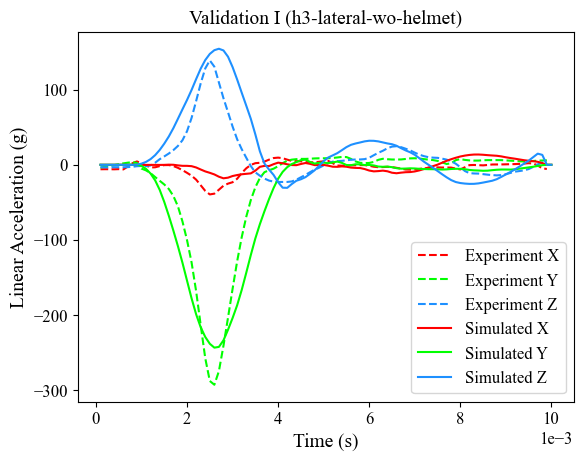

In [2]:
num_pattern = r"[+-]?\d+\.\d+E[+-]?\d+"
time_pattern = r"at time\s*([+-]?\d+\.\d+E[+-]?\d+)"

accels = []
rot_accels = []
current_time = None

with open("nodout") as f:
    nodout = f.readlines()

for i, step in enumerate(nodout):
    time_match = re.search(time_pattern, step)
    if time_match:
        current_time = float(time_match.group(1))
    if "x-disp" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            accels.append((current_time, *nums[6:9]))
    elif "x-rot" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            rot_accels.append((current_time, *nums[6:9]))

accel_df = pd.DataFrame(accels, columns=["Time", "X", "Y", "Z"]).loc[3185:3284]
rot_accel_df = pd.DataFrame(rot_accels, columns=["Time", "X", "Y", "Z"]).loc[3185:3284]

time = np.linspace(0.0001, 0.01, 100)
lit_x = pd.read_csv("literature_X.csv", header=None)
lit_y = pd.read_csv("literature_Y.csv", header=None)
lit_z = pd.read_csv("literature_Z.csv", header=None)

plt.plot(lit_x[0], lit_x[1], color="r", label="Experiment X", linestyle="--")
plt.plot(lit_y[0], lit_y[1], color="lime", label="Experiment Y", linestyle="--")
plt.plot(lit_z[0], lit_z[1], color="dodgerblue", label="Experiment Z", linestyle="--")

plt.plot(
    time,
    cfc(accel_df["X"] * -101.9716, time),
    color="r",
    label="Simulated X",
)
plt.plot(
    time,
    cfc(accel_df["Y"] * -101.9716, time),
    color="lime",
    label="Simulated Y",
)
plt.plot(
    time,
    cfc(accel_df["Z"] * 101.9716, time),
    color="dodgerblue",
    label="Simulated Z",
)

plt.legend()
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Linear Acceleration (g)", fontsize=14)
plt.title("Validation I (h3-lateral-wo-helmet)", fontsize=14)
plt.ticklabel_format(axis="x", style="sci", scilimits=(-3, -3))